## **Load Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
pd.options.mode.chained_assignment = None

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# Download components
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## **Load Data**

In [2]:
sales = pd.read_csv("/content/drive/MyDrive/CIND 820/Milestone 3/sales_compressed.csv")

## **One-Hot Encoding**

In [3]:
# Apply one-hot encoding to the categorical predictors
sales = pd.get_dummies(sales, columns=['rating'], dtype=int)

In [4]:
# Preview newly added columns
sales.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,rating_3.9,rating_4.0,rating_4.1,rating_4.2,rating_4.3
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,0,0,0,1,0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,0,1,0,0,0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,1,0,0,0,0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,0,0,0,1,0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,0,0,0,1,0


## **Train-Test Split**

In [5]:
X = sales[['actual_price', 'discounted_price', 'discount_percentage', 'rating_3.9', 'rating_4.0', 'rating_4.1', 'rating_4.2', 'rating_4.3', 'rating_count']] # Predictors
y = sales['category'] # Target
# 80% of the data is for training, 20% is for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Treatment of Outliers**

In [6]:
# Actual price

# Determine lower and upper bounds for outliers
Q1 = X_train['actual_price'].quantile(0.25)
Q3 = X_train['actual_price'].quantile(0.75)

IQR = Q3 - Q1

min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

# Replace with median
median_val = X_train['actual_price'].median()

outliers = (X_train['actual_price'] < min_val) | (X_train['actual_price'] > max_val)
X_train['actual_price'] = np.where(outliers, median_val, X_train['actual_price'])

outliers = (X_test['actual_price'] < min_val) | (X_test['actual_price'] > max_val)
X_test['actual_price'] = np.where(outliers, median_val, X_test['actual_price'])

# Discounted Price

# Determine lower and upper bounds for outliers
Q1 = X_train['discounted_price'].quantile(0.25)
Q3 = X_train['discounted_price'].quantile(0.75)

IQR = Q3 - Q1

min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

# Replace with median
median_val = X_train['discounted_price'].median()

outliers = (X_train['discounted_price'] < min_val) | (X_train['discounted_price'] > max_val)
X_train['discounted_price'] = np.where(outliers, median_val, X_train['discounted_price'])

outliers = (X_test['discounted_price'] < min_val) | (X_test['discounted_price'] > max_val)
X_test['discounted_price'] = np.where(outliers, median_val, X_test['discounted_price'])

# Discount percentage

# Determine lower and upper bounds for outliers
Q1 = X_train['discount_percentage'].quantile(0.25)
Q3 = X_train['discount_percentage'].quantile(0.75)

IQR = Q3 - Q1

min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

# Replace with median
median_val = X_train['discount_percentage'].median()

outliers = (X_train['discount_percentage'] < min_val) | (X_train['discount_percentage'] > max_val)
X_train['discount_percentage'] = np.where(outliers, median_val, X_train['discount_percentage'])

outliers = (X_test['discount_percentage'] < min_val) | (X_test['discount_percentage'] > max_val)
X_test['discount_percentage'] = np.where(outliers, median_val, X_test['discount_percentage'])

# Rating count

# Determine lower and upper bounds for outliers
Q1 = X_train['rating_count'].quantile(0.25)
Q3 = X_train['rating_count'].quantile(0.75)

IQR = Q3 - Q1

min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

# Replace with median
median_val = X_train['rating_count'].median()

outliers = (X_train['rating_count'] < min_val) | (X_train['rating_count'] > max_val)
X_train['rating_count'] = np.where(outliers, median_val, X_train['rating_count'])

outliers = (X_test['rating_count'] < min_val) | (X_test['rating_count'] > max_val)
X_test['rating_count'] = np.where(outliers, median_val, X_test['rating_count'])

## **Multinomial Logistic Regression**

In [7]:
# Normalize the numerical data
scaler = StandardScaler()
X_train_regression = scaler.fit_transform(X_train[['actual_price', 'discounted_price', 'discount_percentage', 'rating_count']])
X_test_regression = scaler.fit_transform(X_test[['actual_price', 'discounted_price', 'discount_percentage', 'rating_count']])

# Join the one-hot encoded columns with the scaled features
X_train_regression = np.hstack((X_train_regression, X_train[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].to_numpy()))
X_test_regression = np.hstack((X_test_regression, X_test[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].to_numpy()))

# Build model
reg_model = LogisticRegression(max_iter=200)
reg_model.fit(X_train_regression, y_train.to_numpy())

LogisticRegression(max_iter=200)

In [8]:
# Oorder of categories
reg_model.classes_

array(['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
       'Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear',
       'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
       'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
       'Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones',
       'Electronics|WearableTechnology|SmartWatches'], dtype=object)

In [9]:
# Model coefficients
coefficients = pd.DataFrame(reg_model.coef_, columns=['actual_price', 'discounted_price', 'discount_percentage', 'rating_3.9', 'rating_4.0', 'rating_4.1', 'rating_4.2', 'rating_4.3', 'rating_count'])
coefficients.index = ['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']
coefficients

,actual_price,discounted_price,discount_percentage,rating_3.9,rating_4.0,rating_4.1,rating_4.2,rating_4.3,rating_count
Cables|USBCables,-3.839253,-2.019376,1.039688,0.343665,-0.432881,0.374817,-0.200167,0.079738,0.172487
Headphones|In-Ear,-0.474158,-0.500091,-0.071931,0.772091,0.794809,-0.537943,1.047642,-0.038661,-1.258027
Accessories|RemoteControls,-0.595886,-0.484847,0.678324,-2.050750,0.367412,0.356988,-1.237202,0.737486,-0.243184
Televisions|SmartTelevisions,1.556468,1.231851,-0.737942,-0.074337,-0.657574,-0.789885,-0.568418,0.678032,1.332212
Smartphones&BasicMobiles|Smartphones,1.817254,1.438559,-2.524074,0.054922,0.200811,0.197002,0.518561,-0.861373,-0.025846
WearableTechnology|SmartWatches,1.535574,0.333904,1.615934,0.954408,-0.272577,0.399020,0.439585,-0.595222,0.022358


In [10]:
# Model evaluation

y_pred = reg_model.predict(X_test_regression) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.91      0.91      0.91        46
                   Headphones|In-Ear       0.25      0.20      0.22         5
          Accessories|RemoteControls        nan      0.00      0.00         4
        Televisions|SmartTelevisions       0.77      0.91      0.83        11
Smartphones&BasicMobiles|Smartphones       0.56      0.71      0.62         7
     WearableTechnology|SmartWatches       0.77      0.83      0.80        12

                            accuracy                           0.80        85
                           macro avg       0.65      0.59      0.57        85
                        weighted avg       0.80      0.80      0.78        85



## **KNN**

In [11]:
# Apply min-max scaling to the numerical features
scaler = MinMaxScaler()
X_train_knn = scaler.fit_transform(X_train[['actual_price', 'discounted_price', 'discount_percentage', 'rating_count']])
X_test_knn = scaler.fit_transform(X_test[['actual_price', 'discounted_price', 'discount_percentage', 'rating_count']])

# Join the one-hot encoded columns with the scaled features
X_train_knn = np.hstack((X_train_knn, X_train[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].to_numpy()))
X_test_knn = np.hstack((X_test_knn, X_test[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].to_numpy()))

# Train the model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_knn, y_train.to_numpy())

KNeighborsClassifier()

In [12]:
# Model evaluation

y_pred = knn_model.predict(X_test_knn) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.87      0.89      0.88        46
                   Headphones|In-Ear       0.50      0.60      0.55         5
          Accessories|RemoteControls       0.25      0.25      0.25         4
        Televisions|SmartTelevisions       0.62      0.73      0.67        11
Smartphones&BasicMobiles|Smartphones       0.57      0.57      0.57         7
     WearableTechnology|SmartWatches       1.00      0.67      0.80        12

                            accuracy                           0.76        85
                           macro avg       0.63      0.62      0.62        85
                        weighted avg       0.78      0.76      0.77        85



## **Decision Tree**

In [13]:
# Convert the one-hot encoded columns back to the original
X_train['rating'] = X_train[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].idxmax(axis=1).str.replace('rating_', '').astype(float)
X_train = X_train.drop(columns=["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"])

X_test['rating'] = X_test[["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"]].idxmax(axis=1).str.replace('rating_', '').astype(float)
X_test = X_test.drop(columns=["rating_3.9", "rating_4.0", "rating_4.1", "rating_4.2", "rating_4.3"])

# Build model
tree_model = DecisionTreeClassifier(max_depth=5)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [14]:
# Model evaluation

y_pred = tree_model.predict(X_test) # Obtain predictions using test data

# Accuracy, precision, recall
print(classification_report(y_test, y_pred, zero_division = np.nan, target_names=['Cables|USBCables',
 'Headphones|In-Ear',
 'Accessories|RemoteControls',
 'Televisions|SmartTelevisions',
 'Smartphones&BasicMobiles|Smartphones',
 'WearableTechnology|SmartWatches']))

                                      precision    recall  f1-score   support

                    Cables|USBCables       0.94      1.00      0.97        46
                   Headphones|In-Ear       0.75      0.60      0.67         5
          Accessories|RemoteControls        nan      0.00      0.00         4
        Televisions|SmartTelevisions       0.77      0.91      0.83        11
Smartphones&BasicMobiles|Smartphones       0.83      0.71      0.77         7
     WearableTechnology|SmartWatches       0.85      0.92      0.88        12

                            accuracy                           0.88        85
                           macro avg       0.83      0.69      0.69        85
                        weighted avg       0.88      0.88      0.86        85



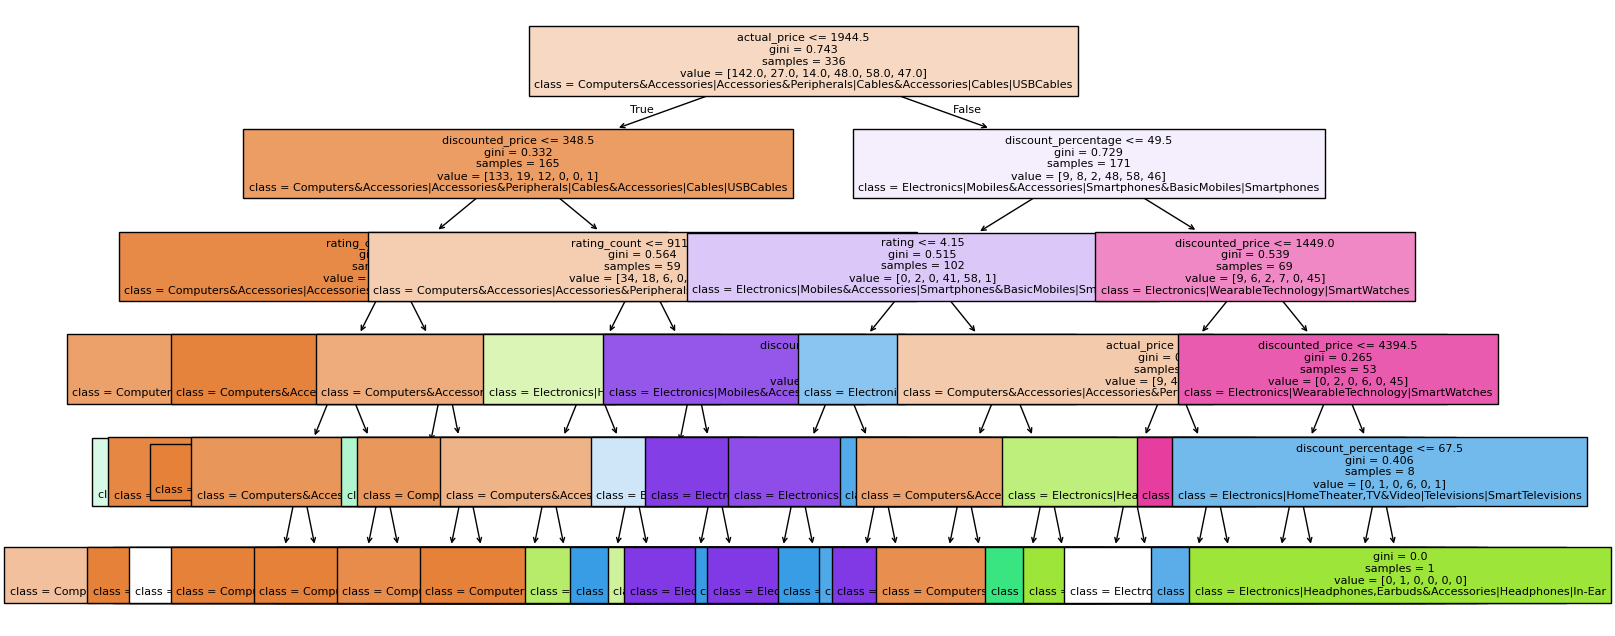

In [15]:
# Visualize the tree
plt.figure(figsize=(15, 8))
plot_tree(tree_model,
          filled=True,
          fontsize=8,
          feature_names=list(X_train.columns),
          class_names=['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
       'Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear',
       'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
       'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
       'Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones',
       'Electronics|WearableTechnology|SmartWatches'])
plt.show()

## **Information Retrieval Pipeline**

In [16]:
# Filter data to include product descriptions and category
products = sales[["category", "about_product"]]
products['id'] = [f'Doc{i+1:02d}' for i in range(len(products))]
products.head()

,category,about_product,id
0,Computers&Accessories|Accessories&Peripherals|...,High Compatibility : Compatible With iPhone 12...,Doc01
1,Computers&Accessories|Accessories&Peripherals|...,"Compatible with all Type C enabled devices, be...",Doc02
2,Computers&Accessories|Accessories&Peripherals|...,【 Fast Charger& Data Sync】-With built-in safet...,Doc03
3,Computers&Accessories|Accessories&Peripherals|...,The boAt Deuce USB 300 2 in 1 cable is compati...,Doc04
4,Computers&Accessories|Accessories&Peripherals|...,[CHARGE & SYNC FUNCTION]- This cable comes wit...,Doc05


In [17]:
# Apply text pre-processing

# Initialize resources
stop_en = set(stopwords.words('english'))
lemm = WordNetLemmatizer()
stemmer = PorterStemmer()

def text_processing(text: str) -> str:
    text = str(text).lower()                                 # Lowercasing
    text = re.sub(r'\d+', ' num ', text)                     # Replace digits with the string 'num'
    tokens = word_tokenize(text)                             # Tokenization
    tokens = [t for t in tokens if t.isalpha()]              # Remove non-alphabetic tokens
    tokens = [t for t in tokens if t not in stop_en]         # Stopword removal
    tokens = [lemm.lemmatize(t) for t in tokens]             # Lemmatization
    tokens = [stemmer.stem(t) for t in tokens]               # Stemming
    return ' '.join(tokens)

# Pre-process each of the product descriptions
products['clean_about_product'] = products['about_product'].astype(str).apply(text_processing)
products[['id', 'clean_about_product']].head()

,id,clean_about_product
0,Doc01,high compat compat iphon num num iphon num num...
1,Doc02,compat type c enabl devic android smartphon mi...
2,Doc03,fast charger data safeti proctect copper wire ...
3,Doc04,boat deuc usb num num num cabl compat smartpho...
4,Doc05,charg sync function cabl come charg data sync ...


In [18]:
# Unigram TF and TF-IDF
tfidf_uni = TfidfVectorizer(ngram_range=(1,1), min_df=5, norm='l2')
X_uni_tfidf = tfidf_uni.fit_transform(products['clean_about_product'])

# Dimensions of matricies (rows = documents, columns = terms)
X_uni_tfidf.shape

(421, 935)

In [19]:
# Model evaluation

# Compute cosine similarity between all documents and extract scores for the Doc401
similarities = cosine_similarity(X_uni_tfidf, X_uni_tfidf)[400]

# Find the top similar products to Doc401
ranked_indices = np.argsort(similarities)[::-1]
similar_products = [(products['id'].iloc[i], products['category'].iloc[i], products['about_product'].iloc[i], float(similarities[i])) for i in ranked_indices][:5]
pd.DataFrame(similar_products, columns=["ID", "Category", "Description", "Cosine Similarity"])

,ID,Category,Description,Cosine Similarity
0,Doc401,Electronics|WearableTechnology|SmartWatches,"1.75” TruViewTM display: See the clear, bigger...",1.000000
1,Doc319,Electronics|WearableTechnology|SmartWatches,"1.75” TruViewTM display : See the clear, bigge...",0.693273
2,Doc410,Electronics|WearableTechnology|SmartWatches,1.55 Always-on AMOLED Display with high 314 PP...,0.496244
3,Doc371,Electronics|WearableTechnology|SmartWatches,[10-day battery]: With a battery backup of 10 ...,0.467815
4,Doc274,Electronics|WearableTechnology|SmartWatches,[10-day battery]: With a battery backup of 10 ...,0.467815


## **Convert to HTML**

In [20]:
!pip install nbconvert

In [21]:
!jupyter nbconvert --to html "/content/drive/MyDrive/CIND 820/Milestone 3/Model_Development_Evaluation.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/CIND 820/Milestone 3/Model_Development_Evaluation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 661872 bytes to /content/drive/MyDrive/CIND 820/Milestone 3/Model_Development_Evaluation.html
